<a href="https://colab.research.google.com/github/ahmedessam-14/Advanced-NLP-Sentiment-Analysis/blob/main/deep_learning_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
X_train = train_df['text']
y_train = train_df['label']

X_test = test_df['text']
y_test = test_df['label']

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GlobalAveragePooling1D

model = Sequential([
    Embedding(input_dim=10000, output_dim=16, input_length=100),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7592 - loss: 0.4990 - val_accuracy: 0.8460 - val_loss: 0.3543
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8786 - loss: 0.2934 - val_accuracy: 0.8528 - val_loss: 0.3303
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9053 - loss: 0.2420 - val_accuracy: 0.8512 - val_loss: 0.3380
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9193 - loss: 0.2121 - val_accuracy: 0.8397 - val_loss: 0.3843
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9304 - loss: 0.1878 - val_accuracy: 0.8468 - val_loss: 0.3767


In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)

print("Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8468 - loss: 0.3767
Accuracy: 0.8468000292778015


In [ ]:
sample = ["I love this movie"]

seq = tokenizer.texts_to_sequences(sample)
pad = pad_sequences(seq, maxlen=100)

prediction = model.predict(pad)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[0.6034493]]


In [ ]:
if prediction[0][0] > 0.5:
    print("Positive 😊")
else:
    print("Negative 😡")

Positive 😊


In [ ]:
samples = [
    "I love this movie",
    "This is the worst film ever",
    "Amazing acting and story",
    "Very boring and bad"
]

for s in samples:
    seq = tokenizer.texts_to_sequences([s])
    pad = pad_sequences(seq, maxlen=100)
    pred = model.predict(pad)[0][0]

    sentiment = "Positive 😊" if pred > 0.5 else "Negative 😡"

    print(s, "=>", sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
I love this movie => Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
This is the worst film ever => Negative 😡
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Amazing acting and story => Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Very boring and bad => Negative 😡


In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9389 - loss: 0.1676 - val_accuracy: 0.8302 - val_loss: 0.4398
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9452 - loss: 0.1524 - val_accuracy: 0.8366 - val_loss: 0.4395
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9507 - loss: 0.1411 - val_accuracy: 0.8289 - val_loss: 0.4835
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9553 - loss: 0.1288 - val_accuracy: 0.8281 - val_loss: 0.5103
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9626 - loss: 0.1173 - val_accuracy: 0.8230 - val_loss: 0.5655


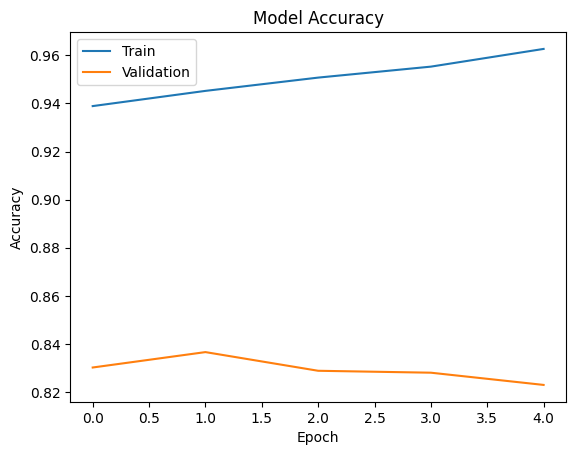

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from tensorflow.keras.layers import Bidirectional

model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [ ]:
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 79s 378ms/step - accuracy: 0.7488 - loss: 0.4812 - val_accuracy: 0.8519 - val_loss: 0.3389
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 79s 363ms/step - accuracy: 0.8917 - loss: 0.2693 - val_accuracy: 0.8414 - val_loss: 0.3552
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 70s 356ms/step - accuracy: 0.9222 - loss: 0.2041 - val_accuracy: 0.8391 - val_loss: 0.4235
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 76s 389ms/step - accuracy: 0.9452 - loss: 0.1482 - val_accuracy: 0.8431 - val_loss: 0.4204
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 77s 360ms/step - accuracy: 0.9642 - loss: 0.0999 - val_accuracy: 0.8343 - val_loss: 0.4918


In [ ]:
loss, acc = model_lstm.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.8343 - loss: 0.4918
LSTM Accuracy: 0.8342800140380859


In [ ]:
print("Naive Bayes Accuracy: 0.86")
print("LSTM Accuracy:", acc)

Naive Bayes Accuracy: 0.86
LSTM Accuracy: 0.8342800140380859


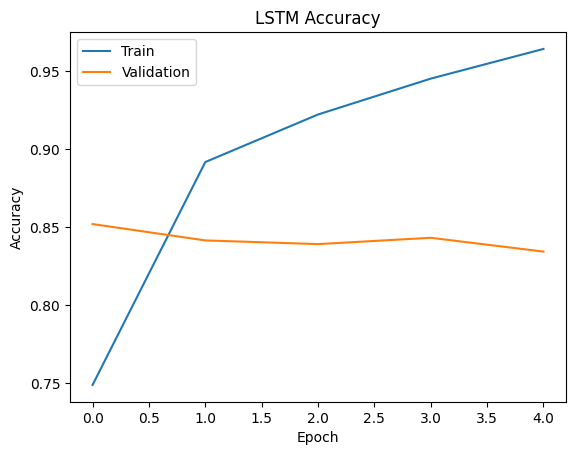

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()